# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Ni Made Anita Widyastini]
- **Email:** [anitadewi8869@gmail.com]
- **ID Dicoding:** [ni_made_anita_widyastini_8gDS]

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda dalam satu tahun?
- Pada jam berapa penyewaan sepeda mencapai puncaknya dalam sehari?
- Bagaimana perbedaan jumlah penyewaan sepeda antara hari kerja dan akhir pekan?

## Import Semua Packages/Library yang Digunakan

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [60]:
# load day dataset
day_url = 'https://drive.google.com/uc?id=1whF1ZGQqAsqHC1PvXB924AivQe6gvf30'
day_df = pd.read_csv(day_url)

# cek data
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [61]:
# load hour dataset
hour_url = 'https://drive.google.com/uc?id=1bPr-KYSj4qETyuuORbMm7OXpfn5-hQKI'
hour_df = pd.read_csv(hour_url)

# cek data
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

Berdasarkan tampilan awal dataset (head), terdapat beberapa informasi penting yang dapat diamati:

- Dataset isinya dari berbagai variabel seperti kondisi waktu, cuaca, dan jumlah penyewaan sepeda. Kolom seperti dteday menunjukkan tanggal, sedangkan hr (pada dataset hour) menunjukkan jam dalam satu hari.

- Variabel seperti season, mnth, weekday, dan workingday menunjukkan waktu untuk melihat pola penggunaan sepeda berdasarkan musim, bulan, hari, maupun hari kerja.

- Variabel weathersit, temp, atemp, hum, dan windspeed untuk kondisi cuaca yang memengaruhi jumlah penyewaan sepeda.

- Dataset juga membedakan jenis pengguna menjadi casual dan registered, serta menyediakan total penyewaan dalam kolom cnt, yang merupakan gabungan dari kedua tipe pengguna tersebut.

- Dari beberapa baris awal, terlihat bahwa jumlah penyewaan (cnt) bervariasi setiap harinya, yang menandakan adanya kemungkinan dipengaruhi oleh waktu maupun kondisi cuaca.

### Assessing Data

In [62]:
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

In [63]:
day_df.isnull().sum()
hour_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [64]:
day_df.duplicated().sum()
hour_df.duplicated().sum()

np.int64(0)

In [65]:
day_df.describe()
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**

Berdasarkan proses assessing data yang telah dilakukan, diperoleh beberapa informasi sebagai berikut:

- Tidak ditemukan missing value pada seluruh kolom di kedua dataset (day_df dan hour_df), sehingga data dapat digunakan tanpa perlu penanganan nilai kosong.

- Tidak terdapat data duplikat pada kedua dataset yang menunjukkan bahwa setiap baris data tidak terjadi pengulangan data.

- Terlihat bahwa jumlah penyewaan sepeda (cnt) memiliki variasi yang cukup besar, dengan nilai minimum sebesar 1 dan maksimum mencapai 977 pada dataset hour_df. Hal ini menandakan adanya pola penggunaan yang bervariasi.

- Jumlah pengguna terdaftar (registered) memiliki rata-rata yang lebih tinggi dibandingkan pengguna casual, yang menunjukkan bahwa sebagian besar penyewaan dilakukan oleh pengguna yang sudah terdaftar. Selain itu, beberapa variabel seperti temp, atemp, hum, dan windspeed memiliki nilai dalam rentang 0 hingga 1, yang menunjukkan bahwa data tersebut telah dinormalisasi.

### Cleaning Data

In [66]:
# Sekarang dteday masih object, harus jadi datetime:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [67]:
#ubah angka jadi kategori
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

day_df['season'] = day_df['season'].map(season_map)
hour_df['season'] = hour_df['season'].map(season_map)

In [68]:
weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain'
}

day_df['weathersit'] = day_df['weathersit'].map(weather_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)

In [69]:
workingday_map = {
    0: 'Weekend',
    1: 'Working Day'
}

day_df['workingday'] = day_df['workingday'].map(workingday_map)
hour_df['workingday'] = hour_df['workingday'].map(workingday_map)

In [70]:
# Tambah Kolom Baru
day_df['year'] = day_df['dteday'].dt.year
day_df['month'] = day_df['dteday'].dt.month

hour_df['year'] = hour_df['dteday'].dt.year
hour_df['month'] = hour_df['dteday'].dt.month

In [71]:
# Merapihkan Nama Kolom
day_df.rename(columns={
    'cnt': 'total_rentals'
}, inplace=True)

hour_df.rename(columns={
    'cnt': 'total_rentals'
}, inplace=True)

In [72]:
day_df.to_csv('data_1.csv', index=False)
hour_df.to_csv('data_2.csv', index=False)

In [73]:
hour_grouped = hour_df.groupby(['dteday', 'hr'])['total_rentals'].mean().reset_index()

# Merge ke day_df
main_df = pd.merge(day_df, hour_grouped, on='dteday', how='left')

In [74]:
# rename nama kolom
main_df.rename(columns={
    'total_rentals_x': 'daily_rentals',
    'total_rentals_y': 'hourly_rentals'
}, inplace=True)

In [75]:
main_df.to_csv('main_data.csv', index=False)

**Insight:**

Pada tahap cleaning data, dilakukan beberapa proses untuk meningkatkan kualitas dan keterbacaan data.

- Kolom dteday yang sebelumnya bertipe object diubah menjadi tipe datetime agar berbasis waktu.

- Beberapa variabel kategorikal seperti season, weathersit, dan workingday yang sebelumnya berupa angka telah diubah menjadi label kategori agar lebih mudah dipahami dalam analisis dan visualisasi.

- Selain itu, dilakukan penambahan kolom baru yaitu year dan month yang diambil dari kolom dteday untuk mempermudah analisis tren berdasarkan waktu.

- Kolom cnt juga telah diubah namanya menjadi total_rentals agar lebih merepresentasikan isi data secara jelas.

- Secara keseluruhan, data sudah dalam kondisi bersih, tidak terdapat missing value maupun duplikasi data, serta siap digunakan untuk tahap analisis selanjutnya.

## Exploratory Data Analysis (EDA)

### Explore ...

In [76]:
# Distribusi penyewaan
day_df['total_rentals'].describe()

# Rata-rata penyewaan berdasarkan musim
season_analysis = day_df.groupby('season')['total_rentals'].mean()
season_analysis

# Rata-rata penyewaan berdasarkan bulan
monthly_analysis = day_df.groupby('mnth')['total_rentals'].mean()
monthly_analysis

# Rata-rata penyewaan berdasarkan jam
hourly_analysis = hour_df.groupby('hr')['total_rentals'].mean()
hourly_analysis

,total_rentals
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


**Insight:**

Berdasarkan hasil analisis rata-rata penyewaan sepeda berdasarkan jam, terlihat pola yang cukup jelas dalam penggunaan sepeda sepanjang hari.

- Jumlah penyewaan sepeda berada pada tingkat paling rendah pada dini hari, khususnya sekitar pukul 03.00–05.00, yang menunjukkan sedikitnya aktivitas pada jam tersebut.

- Mulai pukul 06.00, jumlah penyewaan meningkat dan mencapai puncak pertama pada pukul 08.00. Hal ini menandakan adanya aktivitas penggunaan sepeda pada jam berangkat kerja atau sekolah.

- Setelah itu, jumlah penyewaan cenderung menurun pada siang hari, namun kembali meningkat pada sore hari dan mencapai puncak tertinggi pada pukul 17.00–18.00.

Pola ini menunjukkan bahwa penggunaan sepeda sangat dipengaruhi oleh aktivitas harian masyarakat, terutama pada jam sibuk (rush hour) di pagi dan sore hari.

## Visualization & Explanatory Analysis

### Pertanyaan 1:
Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?

In [77]:
weather_analysis = day_df.groupby('weathersit')['total_rentals'].mean().sort_values(ascending=False)

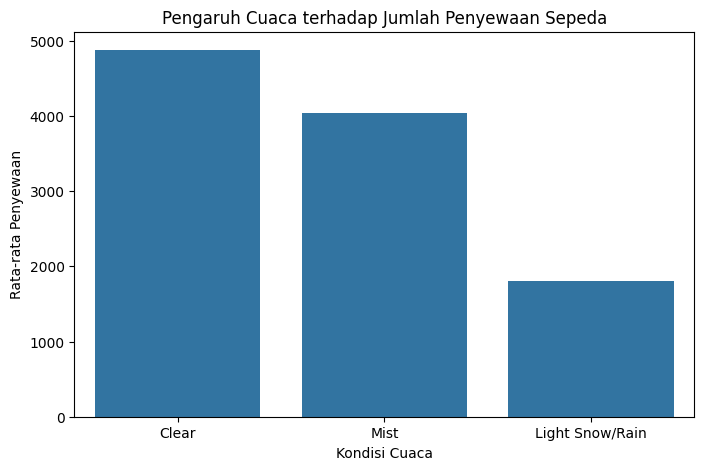

In [78]:
plt.figure(figsize=(8,5))
sns.barplot(x=weather_analysis.index, y=weather_analysis.values)

plt.title('Pengaruh Cuaca terhadap Jumlah Penyewaan Sepeda')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

### Pertanyaan 2:
Pada jam berapa penyewaan sepeda mencapai puncaknya?

In [79]:
hour_df.groupby('hr')['total_rentals'].mean()

,total_rentals
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


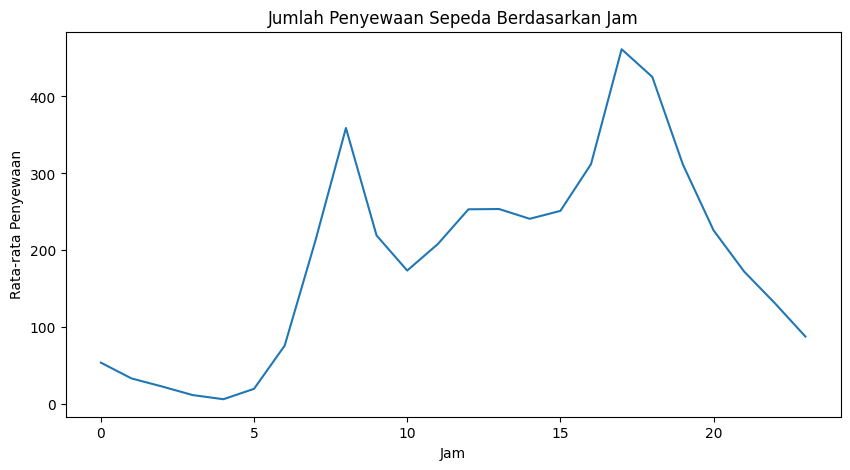

In [80]:
plt.figure(figsize=(10,5))
hour_df.groupby('hr')['total_rentals'].mean().plot()

plt.title('Jumlah Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

### Pertanyaan 3:
Bagaimana perbedaan jumlah penyewaan antara hari kerja dan akhir pekan?

In [81]:
day_df.groupby('workingday')['total_rentals'].mean()

,total_rentals
workingday,
Weekend,4330.168831
Working Day,4584.820000


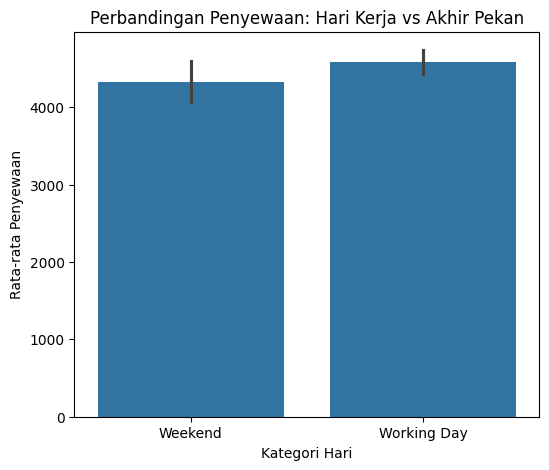

In [82]:
plt.figure(figsize=(6,5))
sns.barplot(x='workingday', y='total_rentals', data=day_df)

plt.title('Perbandingan Penyewaan: Hari Kerja vs Akhir Pekan')
plt.xlabel('Kategori Hari')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:**

Berdasarkan hasil analisis data penyewaan sepeda, dapat disimpulkan bahwa terdapat beberapa faktor utama yang memengaruhi jumlah penyewaan, yaitu kondisi cuaca, waktu (jam), dan jenis hari (hari kerja atau akhir pekan).

- Dari sisi kondisi cuaca, jumlah penyewaan sepeda paling tinggi terjadi pada kondisi cuaca cerah, dan akan menurun seiring memburuknya kondisi cuaca. Hal ini menunjukkan bahwa cuaca memiliki pengaruh terhadap minat masyarakat dalam menggunakan sepeda.

- Berdasarkan waktu (jam), ditemukan pola yang sangat jelas di mana penyewaan sepeda mencapai puncaknya pada jam sibuk, yaitu sekitar pukul 08.00 dan 17.00–18.00. Pola ini mengindikasikan bahwa sepeda banyak digunakan sebagai sarana transportasi untuk aktivitas harian seperti berangkat dan pulang kerja.

- Selain itu, jika dilihat dari jenis hari, jumlah penyewaan sepeda pada hari kerja lebih tinggi dibandingkan akhir pekan. Hal ini memperkuat bahwa sepeda lebih sering digunakan untuk kebutuhan rutin saat weekdays dibandingkan untuk aktivitas rekreasi.

Secara keseluruhan, dapat disimpulkan bahwa penggunaan sepeda sangat dipengaruhi oleh faktor seperti cuaca dan waktu, serta pola aktivitas masyarakat dalam kehidupan sehari-hari.

## Analisis Lanjutan (Opsional)

In [83]:
# Buat kategori berdasarkan kondisi
def categorize(row):
    if row['total_rentals'] > 5000 and row['temp'] > 0.5:
        return 'High Demand'
    elif row['total_rentals'] < 2000:
        return 'Low Demand'
    else:
        return 'Medium Demand'

day_df['demand_category'] = day_df.apply(categorize, axis=1)

# Lihat distribusi
day_df['demand_category'].value_counts()

,count
demand_category,
Medium Demand,425
High Demand,208
Low Demand,98


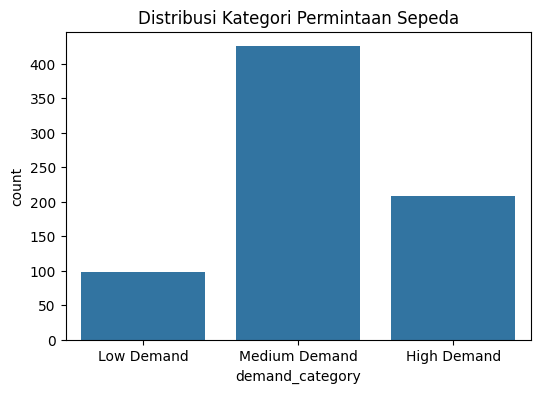

In [84]:
day_df.groupby('demand_category')[['temp', 'hum', 'windspeed']].mean()

plt.figure(figsize=(6,4))
sns.countplot(x='demand_category', data=day_df, order=['Low Demand','Medium Demand','High Demand'])
plt.title('Distribusi Kategori Permintaan Sepeda')
plt.show()

**Insight:**

- Berdasarkan hasil pengelompokan (clustering) permintaan sepeda, terlihat bahwa sebagian besar data berada pada kategori Medium Demand, diikuti oleh High Demand, dan paling sedikit pada Low Demand. Hal ini menunjukkan bahwa secara umum tingkat penyewaan sepeda cenderung stabil pada level sedang.

- Dari analisis lebih lanjut terhadap faktor lingkungan, diketahui bahwa kategori High Demand cenderung terjadi pada kondisi suhu yang lebih tinggi dibandingkan kategori lainnya. Hal ini mengindikasikan bahwa cuaca yang lebih hangat mendorong peningkatan aktivitas penyewaan sepeda.

- Sebaliknya, kategori Low Demand memiliki jumlah paling sedikit dan umumnya terjadi pada kondisi yang kurang mendukung, seperti suhu yang lebih rendah atau kondisi lingkungan tertentu.

Analisis lanjutan dengan teknik clustering berbasis manual grouping ini dilakukan untuk mengelompokkan data penyewaan sepeda ke dalam kategori tingkat permintaan (High, Medium, Low) berdasarkan kombinasi variabel seperti jumlah penyewaan dan kondisi cuaca, supaya pola demand bisa dilihat secara lebih menyeluruh dan gampang dipahami.

## Conclusion

- Conclusion pertanyaan 1:

Kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Penyewaan sepeda paling tinggi terjadi pada kondisi cuaca cerah, dan akan menurun seiring dengan memburuknya kondisi cuaca. Hal ini menunjukkan bahwa faktor cuaca menjadi salah satu penentu utama dalam penggunaan sepeda oleh masyarakat.

- Conclusion pertanyaan 2:

Penyewaan sepeda mencapai puncaknya pada jam sibuk, yaitu sekitar pukul 08.00 serta 17.00–18.00, dengan puncak tertinggi terjadi pada pukul 17.00. Pola ini menunjukkan bahwa sepeda banyak digunakan sebagai sarana transportasi untuk aktivitas harian, terutama pada waktu berangkat dan pulang kerja.

- Conclusion pertanyaan 3:

Terdapat perbedaan jumlah penyewaan sepeda antara hari kerja dan akhir pekan, di mana penyewaan lebih tinggi pada hari kerja. Hal ini menunjukkan bahwa sepeda lebih sering digunakan untuk kebutuhan mobilitas rutin dibandingkan untuk aktivitas rekreasi.